# Домашнее задание 1. Биоинформатика, 2-й год, 2-й семестр. Код.

Выполнил Махлин Мирон

## Часть 1

In [19]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("dada2", update = FALSE)
BiocManager::install("phyloseq", update = FALSE)

library(dada2)
library(phyloseq)
packageVersion("dada2")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://mirror.truenetwork.ru/CRAN/



Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://mirror.truenetwork.ru/CRAN/

Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)

Загрузка требуемого пакета: Rcpp



[1] ‘1.30.0’

In [20]:
path <- "./data/Dat2"
fnFs <- sort(list.files(path, pattern = ".R1.fastq.gz", full.names = TRUE))
fnRs <- sort(list.files(path, pattern = ".R2.fastq.gz", full.names = TRUE))

In [ ]:
sample.names <- gsub(".R1.fastq.gz", "", basename(fnFs))

In [ ]:
sample.names

[1] "25" "26" "27" "28" "29" "30" "31" "32" "33" "34" "35" "36" "37" "38"

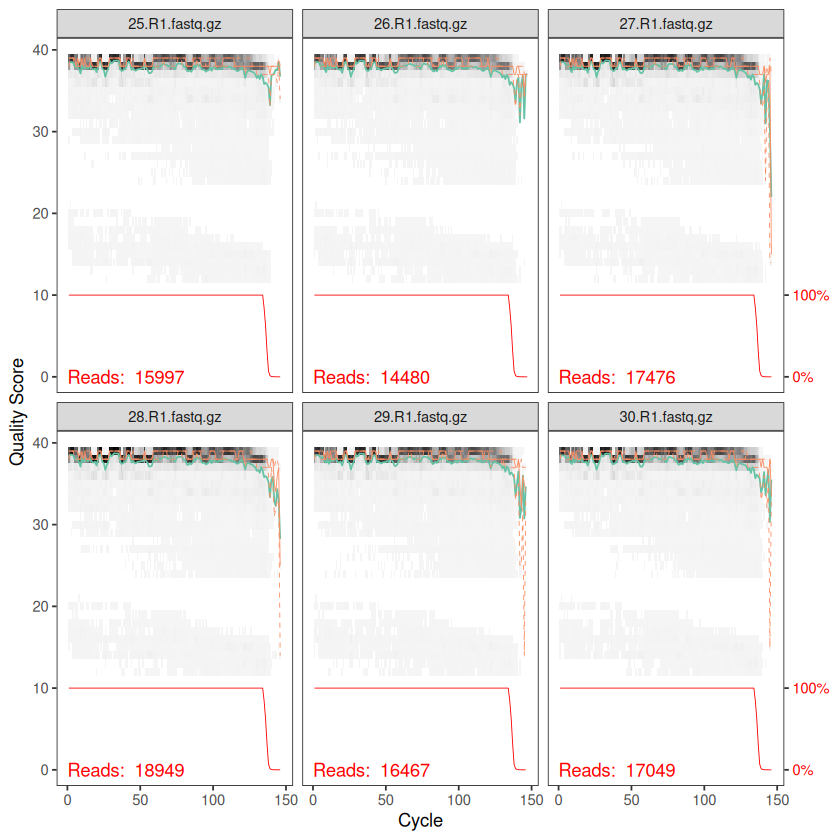

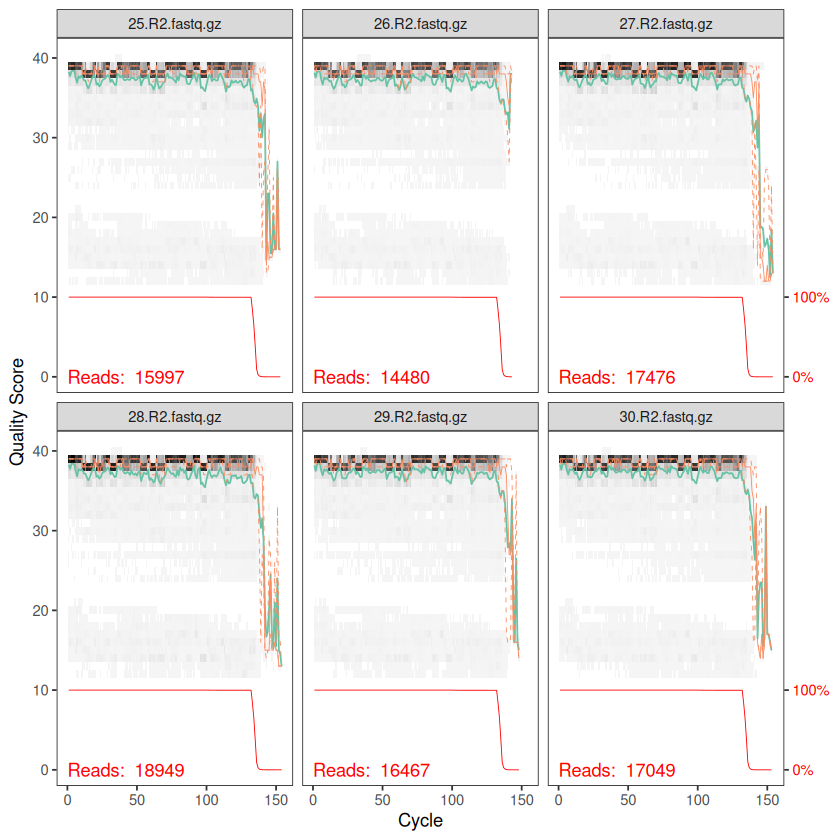

In [ ]:
plotQualityProfile(fnFs[1:6])
plotQualityProfile(fnRs[1:6])

In [31]:
filtFs <- file.path(path, "filtered", paste0(sample.names, "_F_filt.fastq.gz"))
filtRs <- file.path(path, "filtered", paste0(sample.names, "_R_filt.fastq.gz"))
names(filtFs) <- sample.names
names(filtRs) <- sample.names

out <- filterAndTrim(fnFs, filtFs, fnRs, filtRs,
                     truncLen = c(130, 130),
                     maxEE = c(2,2),
                     maxN = 0,
                     truncQ = 2,
                     rm.phix = TRUE,
                     compress = TRUE,
                     multithread = TRUE)

head(out)

,reads.in,reads.out
25.R1.fastq.gz,15997,15656
26.R1.fastq.gz,14480,14182
27.R1.fastq.gz,17476,17150
28.R1.fastq.gz,18949,18561
29.R1.fastq.gz,16467,16155
30.R1.fastq.gz,17049,16735


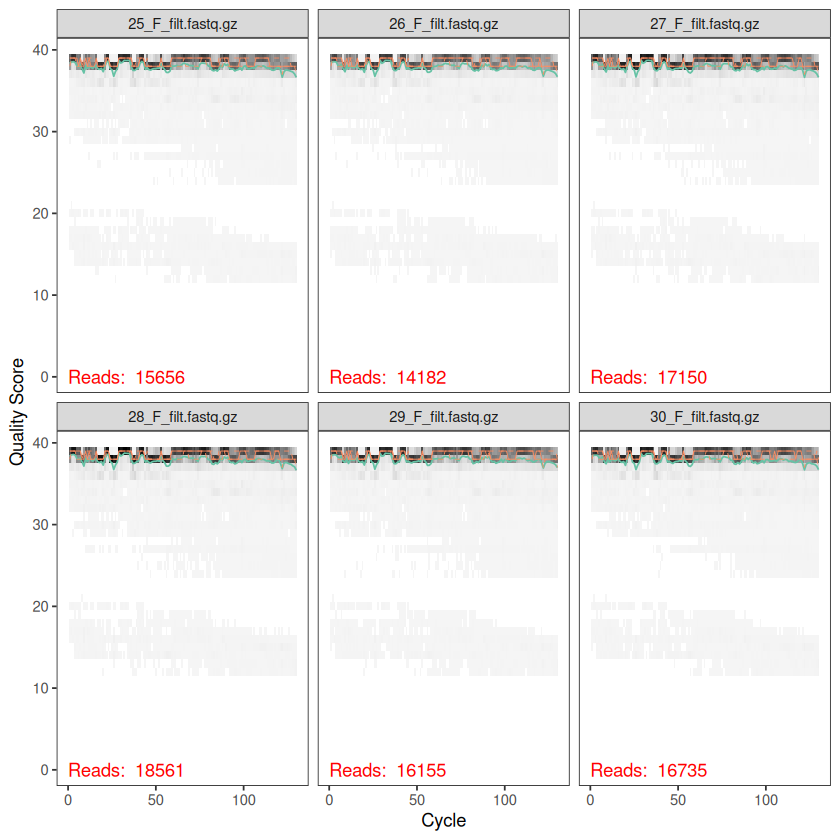

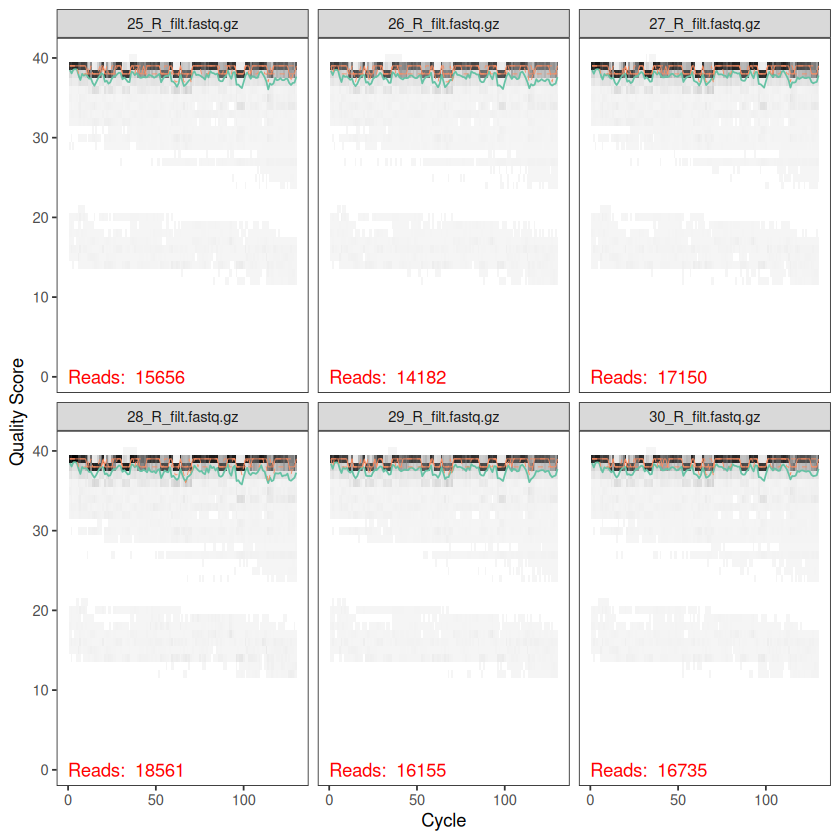

In [32]:
plotQualityProfile(filtFs[1:6])
plotQualityProfile(filtRs[1:6])

29695640 total bases in 228428 reads from 14 samples will be used for learning the error rates.
29695640 total bases in 228428 reads from 14 samples will be used for learning the error rates.


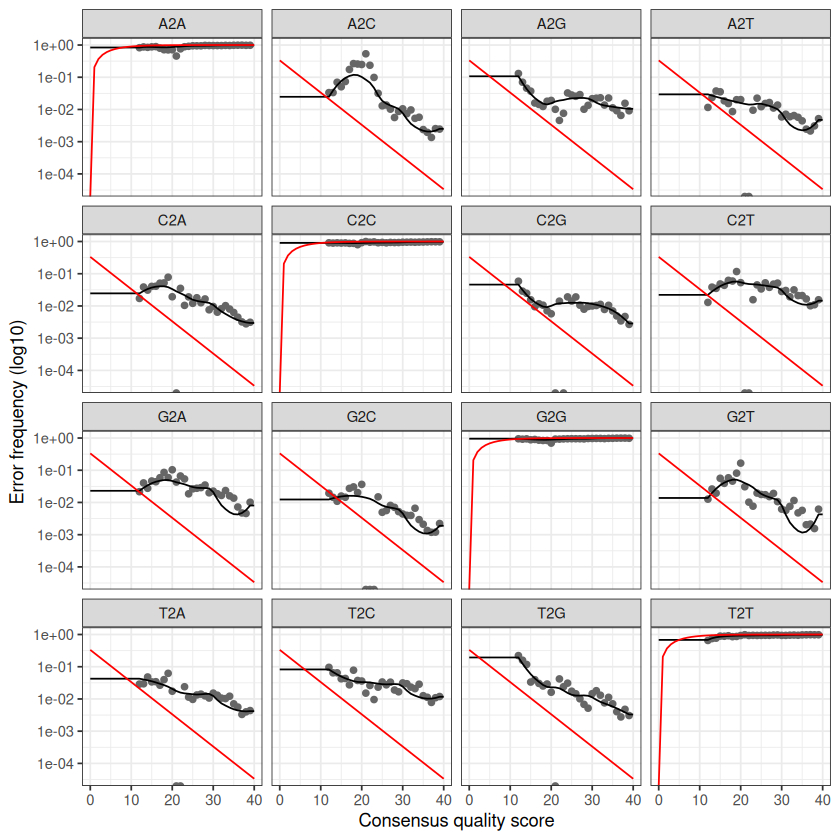

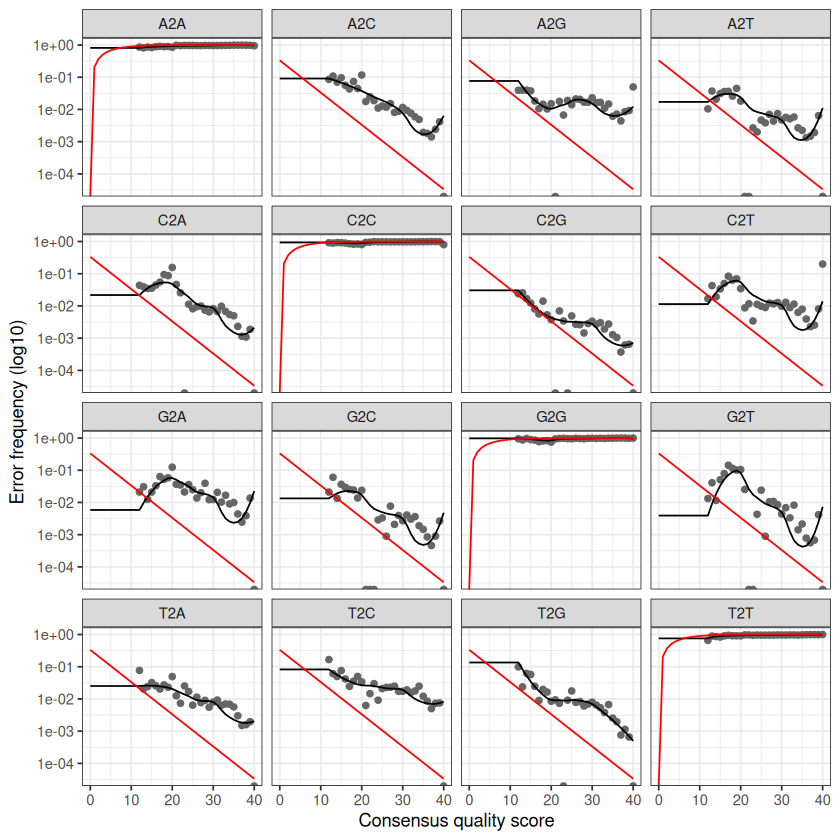

In [33]:
errF <- learnErrors(filtFs, multithread = TRUE)
errR <- learnErrors(filtRs, multithread = TRUE)

plotErrors(errF, nominalQ = TRUE)
plotErrors(errR, nominalQ = TRUE)

In [34]:
dadaFs <- dada(filtFs, err = errF, multithread = TRUE)
dadaRs <- dada(filtRs, err = errR, multithread = TRUE)

Sample 1 - 15656 reads in 5587 unique sequences.
Sample 2 - 14182 reads in 5382 unique sequences.
Sample 3 - 17150 reads in 6044 unique sequences.
Sample 4 - 18561 reads in 6984 unique sequences.
Sample 5 - 16155 reads in 5725 unique sequences.
Sample 6 - 16735 reads in 6378 unique sequences.
Sample 7 - 16610 reads in 5977 unique sequences.
Sample 8 - 15140 reads in 5568 unique sequences.
Sample 9 - 15115 reads in 5540 unique sequences.
Sample 10 - 16311 reads in 5968 unique sequences.
Sample 11 - 16321 reads in 6032 unique sequences.
Sample 12 - 16919 reads in 5977 unique sequences.
Sample 13 - 16280 reads in 6249 unique sequences.
Sample 14 - 17293 reads in 6342 unique sequences.
Sample 1 - 15656 reads in 5218 unique sequences.
Sample 2 - 14182 reads in 4841 unique sequences.
Sample 3 - 17150 reads in 5646 unique sequences.
Sample 4 - 18561 reads in 6701 unique sequences.
Sample 5 - 16155 reads in 5124 unique sequences.
Sample 6 - 16735 reads in 5600 unique sequences.
Sample 7 - 1661

In [35]:
mergers <- mergePairs(dadaFs, filtFs, dadaRs, filtRs,
                      verbose = TRUE, minOverlap = 9)

12884 paired-reads (in 739 unique pairings) successfully merged out of 14708 (in 1744 pairings) input.

11563 paired-reads (in 673 unique pairings) successfully merged out of 13113 (in 1383 pairings) input.

14138 paired-reads (in 820 unique pairings) successfully merged out of 16092 (in 1830 pairings) input.

14661 paired-reads (in 871 unique pairings) successfully merged out of 17269 (in 2182 pairings) input.

13562 paired-reads (in 678 unique pairings) successfully merged out of 15109 (in 1331 pairings) input.

13491 paired-reads (in 758 unique pairings) successfully merged out of 15482 (in 1632 pairings) input.

13469 paired-reads (in 721 unique pairings) successfully merged out of 15439 (in 1740 pairings) input.

12412 paired-reads (in 789 unique pairings) successfully merged out of 14056 (in 1701 pairings) input.

12319 paired-reads (in 661 unique pairings) successfully merged out of 13963 (in 1384 pairings) input.

13182 paired-reads (in 706 unique pairings) successfully merged 

In [36]:
seqtab <- makeSequenceTable(mergers)
dim(seqtab)
table(nchar(getSequences(seqtab)))

[1]   14 4371


 167  250  251 
   1  869 3501 

In [37]:
seqtab.nochim <- removeBimeraDenovo(seqtab, method = "consensus",
                                     multithread = TRUE, verbose = TRUE)
dim(seqtab.nochim)

Identified 1703 bimeras out of 4371 input sequences.



[1]   14 2668

In [38]:
getN <- function(x) sum(getUniques(x))
track <- cbind(out,
               sapply(dadaFs, getN),
               sapply(dadaRs, getN),
               sapply(mergers, getN),
               rowSums(seqtab.nochim))
colnames(track) <- c("input", "filtered", "denoisedF", "denoisedR",
                     "merged", "nonchim")
rownames(track) <- sample.names

track

,input,filtered,denoisedF,denoisedR,merged,nonchim
25,15997,15656,14984,15288,12884,11707
26,14480,14182,13384,13816,11563,10982
27,17476,17150,16429,16721,14138,13042
28,18949,18561,17695,18037,14661,13444
29,16467,16155,15428,15737,13562,12580
30,17049,16735,15808,16306,13491,12579
31,16948,16610,15808,16133,13469,12326
32,15448,15140,14415,14692,12412,11273
33,15385,15115,14302,14670,12319,11373
34,16621,16311,15391,15785,13182,12104


In [78]:

track_df <- data.frame(track)
final_stats <- data.frame(
  Stage = c("Начало (Input)", "После фильтрации", "После объединения", "Итог"),
  Count = c(mean(track_df$input), mean(track_df$filtered), mean(track_df$merged), mean(track_df$nonchim))
)

loss_filter <- round((1 - mean(track_df$filtered) / mean(track_df$input)) * 100, 1)
loss_merge  <- round((1 - mean(track_df$merged)   / mean(track_df$filtered)) * 100, 1)
loss_chim   <- round((1 - mean(track_df$nonchim)  / mean(track_df$merged)) * 100, 1)
total_retention <- round(mean(track_df$nonchim) / mean(track_df$input) * 100, 1)

mean_asv <- mean(rowSums(seqtab.nochim > 0))

cat("Потеряно на фильтрации:", loss_filter, "%\n")
cat("Потеряно на объединении:", loss_merge, "%\n")
cat("Потеряно на химерах:", loss_chim, "%\n")
cat("Итого сохранилось:", total_retention, "%\n")
cat("Среднее число прочтений на образец:", round(mean(track_df$nonchim)), "\n")
cat("Среднее число ASV на образец:", round(mean_asv), "\n")

Потеряно на фильтрации: 1.9 %
Потеряно на объединении: 18.3 %
Потеряно на химерах: 8 %
Итого сохранилось: 73.8 %
Среднее число прочтений на образец: 12269 
Среднее число ASV на образец: 501 


In [39]:
taxa <- assignTaxonomy(seqtab.nochim,
                       "./data/silva_nr99_v138.1_train_set.fa.gz",
                       multithread = TRUE)

taxa <- as.data.frame(taxa)
head(taxa)

,Kingdom,Phylum,Class,Order,Family,Genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
TACAGAGGCCAAGAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGTCTTGCGTGTCAAGTGTGAAATCTCCGGGCCCAACCCGGAAAGTGCGCTTGAAACTACAGGACTCGAGTCTGGGAGAGGGAATCGGAATGCAGGGTGTAGCGGTGAAATGCGTTGATATCCTGCAGAACACCGGAGGCGAAGGCGGATTCCTTGAACAGCACTGACGCTGAGGCGCGAAAGTCGGGGGAGCAAACA,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
TACAGAGGCCAAGAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGTCTTGCGTGTCAAGTGTGAAATCTCCGGGCTCAACCCGGAAAGTGCGCTTGAAACTACAGGACTCGAGTCTGGGAGAGGGAATCGGAATATAGGGTGTAGCGGTGAAATGCGTTGATATCCTATAGAACACCGGAGGCGAAGGCGGATTCCTTGAACAGTACTGACGCTGAGGCGCGAAAGTCGGGGGAGCAAACA,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
TACAGAGGCCAAGAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGTCTTGCGTGTCAAGTGTGAAATCTCCGGGCTCAACCCGGAAAGTGCGCTTGAAACTACAGGACTCGAGTCTGGGAGAGGGAATCGGAATGCAGGGTGTAGCGGTGAAATGCGTTGATATCCTGCAGAACACCGGAGGCGAAGGCGGATTCCTTGAACAGCACTGACGCTGAGGCGCGAAAGTCGGGGGAGCAAACA,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
TACATAGGTTACAAGCGTTATCCGGATTTACTGGGCGTAAAGCGAGCGCAGATGGACTTACAAGTCTGGTGTTAAAGACTTAGGCTTAACCTAAACACGCATTGGAAACTGTAAGTCTAGAGTTTGATAGGAAGTTTTAGAACTCCATGTGGAGCGGTGGAATGCGCAGATATATGGAAGAATACCGGTGGTGAAAACGAAAACTTAGGTCACAACTGACATTTAGGCTCGAAAGTGTGGGGAGCAAATA,Bacteria,Firmicutes,Bacilli,Mycoplasmatales,Mycoplasmataceae,Mycoplasma
TACAGAGGCCAAGAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGTCTTGCGTGTCAAGTGTGAAATCTCCGGGCTCAACCCGGAAAGTGCGCTTGAAACTACAGGACTCGAGTCTGGGAGAGGGAATCGGAATGCAGGGTGTAGCGGTGAAATGCGTTGATATCCTGCAGAACACCGGAGGCGAAGGCGGATTCCTTGAACAGTACTGACGCTGAGGCGCGAAAGTCGGGGGAGCAAACA,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
TACAGAGGCCAAGAGCGTTGTTCGGATTTACTGGGCGTAAAGGGCGCGTAGGCGGTCTTGCGTGTCAAGTGTGAAATCTCCGGGCTCAACCCGGAAAGTGCGCTTGAAACTACAGGACTCGAGTCTGGGAGAGGGAATCGGAATACAGGGTGTAGCGGTGAAATGCGTTGATATCCTGTAGAACACCGGAGGCGAAGGCGGATTCCTTGAACAGTACTGACGCTGAGGCGCGAAAGTCGGGGGAGCAAACA,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA


In [62]:
head(taxa, 50)

,Kingdom,Phylum,Class,Order,Family,Genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
sp1,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
sp2,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
sp3,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
sp4,Bacteria,Firmicutes,Bacilli,Mycoplasmatales,Mycoplasmataceae,Mycoplasma
sp5,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
sp6,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA
sp7,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelatoclostridiaceae,UCG-004
sp8,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelatoclostridiaceae,UCG-004
sp9,Bacteria,Verrucomicrobiota,Kiritimatiellae,WCHB1-41,NA,NA


In [79]:
genera_column <- tax_table(phy)[, "Genus"]
unclassified_count <- sum(is.na(genera_column))
total_asvs <- length(genera_column)
percent_unclassified <- round((unclassified_count / total_asvs) * 100, 1)

cat("Всего ASV в таблице:", total_asvs, "\n")
cat("Количество неклассифицированных родов:", unclassified_count, "\n")
cat("Процент неклассифицированных:", percent_unclassified, "%\n")

Всего ASV в таблице: 2668 
Количество неклассифицированных родов: 1527 
Процент неклассифицированных: 57.2 %


In [41]:
colnames(seqtab.nochim) <- paste0("sp", 1:ncol(seqtab.nochim))
rownames(taxa) <- colnames(seqtab.nochim)

In [42]:
OTU <- otu_table(seqtab.nochim, taxa_are_rows = FALSE)
TAX <- tax_table(as.matrix(taxa))

In [43]:
library(phyloseq)

colnames(seqtab.nochim) <- paste0("sp", 1:ncol(seqtab.nochim))
rownames(taxa) <- colnames(seqtab.nochim)

meta_file <- "Dat2_metadata.csv"
meta_raw <- read.csv(meta_file, header = TRUE, stringsAsFactors = FALSE)

head(meta_raw)

sample_names_col <- meta_raw[, 1]
meta_raw <- meta_raw[, -1, drop = FALSE]
rownames(meta_raw) <- sample_names_col

rownames(meta_raw) <- gsub(".R1.fastq.gz", "", rownames(meta_raw))

otu_samples <- rownames(seqtab.nochim)

meta_raw <- meta_raw[otu_samples, , drop = FALSE]

SAM <- sample_data(meta_raw)

OTU <- otu_table(seqtab.nochim, taxa_are_rows = FALSE)
TAX <- tax_table(as.matrix(taxa))

phy <- phyloseq(OTU, TAX, SAM)

saveRDS(phy, "bee_dat_raw.RDS")

phy

,X,Param1,Param2
,<chr>,<chr>,<chr>
1,25.R1.fastq.gz,Variable1,Variable1
2,26.R1.fastq.gz,Variable2,Variable1
3,27.R1.fastq.gz,Variable2,Variable2
4,28.R1.fastq.gz,Variable2,Variable1
5,29.R1.fastq.gz,Variable2,Variable2
6,30.R1.fastq.gz,Variable1,Variable1


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2668 taxa and 14 samples ]
sample_data() Sample Data:       [ 14 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 2668 taxa by 6 taxonomic ranks ]

## Часть 2

In [46]:
library(phyloseq)
library(ggplot2)
library(vegan)
library(microbiome) 
library(reshape2)
library(pheatmap)
library(dplyr)

phy <- readRDS("bee_dat_raw.RDS")
phy

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2668 taxa and 14 samples ]
sample_data() Sample Data:       [ 14 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 2668 taxa by 6 taxonomic ranks ]

In [48]:
colnames(tax_table(phy))
genus_phy <- tax_glom(phy, taxrank = "Genus")
genus_phy

genus_rel <- transform_sample_counts(genus_phy, function(x) x / sum(x))
prevalence_threshold <- 0.5 * nsamples(genus_phy)
prevdf <- apply(otu_table(genus_rel), 2, function(x) sum(x > 0))
keep_prev <- names(prevdf[prevdf >= prevalence_threshold])

abundance_threshold <- 0.05
keep_abund <- names(which(apply(otu_table(genus_rel), 2, max) >= abundance_threshold))

keep_genus <- intersect(keep_prev, keep_abund)
cat("Number of genera retained:", length(keep_genus), "\n")
genus_filt <- prune_taxa(keep_genus, genus_phy)
genus_filt

saveRDS(genus_filt, "filtered_genus.RDS")

[1] "Kingdom" "Phylum"  "Class"   "Order"   "Family"  "Genus"

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 154 taxa and 14 samples ]
sample_data() Sample Data:       [ 14 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 154 taxa by 6 taxonomic ranks ]

Number of genera retained: 7 


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 7 taxa and 14 samples ]
sample_data() Sample Data:       [ 14 samples by 2 sample variables ]
tax_table()   Taxonomy Table:    [ 7 taxa by 6 taxonomic ranks ]

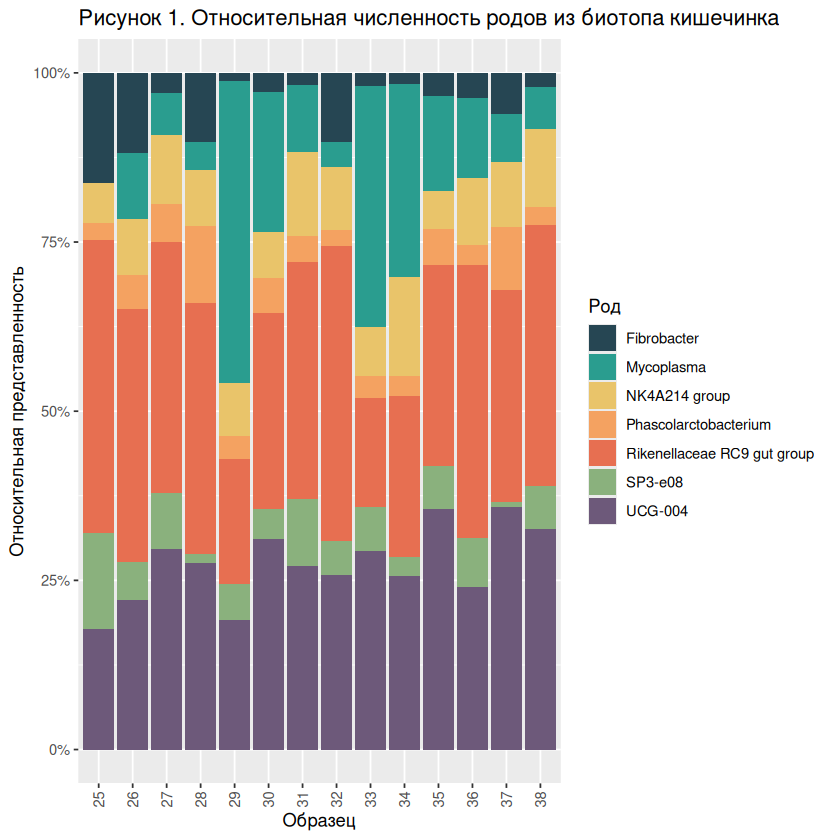

In [70]:
genus_filt_rel <- transform_sample_counts(genus_filt, function(x) x / sum(x))
df_bar <- psmelt(genus_filt_rel)
df_bar$Genus <- as.character(df_bar$Genus)
df_bar$Genus[is.na(df_bar$Genus)] <- "Unclassified"

coolors_palette <- c("#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#8ab17d", "#6d597a")

bar_plot <- ggplot(df_bar, aes(x = Sample, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
  labs(fill="Род", x="Образец", y = "Относительная представленность", title = "Рисунок 1. Относительная численность родов из биотопа кишечинка") +
  scale_fill_manual(values = coolors_palette)

print(bar_plot)
ggsave("barplot_genera.png", width = 10, height = 6)

In [71]:
genus_clr <- microbiome::transform(genus_filt, "clr")

clr_matrix <- as.matrix(otu_table(genus_clr))
if (taxa_are_rows(genus_clr)) {
  clr_matrix <- t(clr_matrix)
}

metadata <- data.frame(sample_data(genus_filt))
annotation_col <- data.frame(Group = metadata[, "Param1"])
rownames(annotation_col) <- rownames(metadata)

colnames(clr_matrix) <- as.character(tax_table(genus_filt)[, "Genus"])
colnames(clr_matrix)[is.na(colnames(clr_matrix))] <- "Unclassified"

pheatmap(clr_matrix,
         annotation_row = annotation_col,
         show_rownames = FALSE,
         main = "Рисунок 2. CLR-трансформированные данные по родам",
         color = colorRampPalette(c("navy", "white", "firebrick"))(100),
         filename = "heatmap_genera.png",
         fontsize_col = 8)

In [51]:
otu_mat <- as.matrix(otu_table(genus_phy))
if (taxa_are_rows(genus_phy)) {
  otu_mat <- t(otu_mat)
}

shannon <- vegan::diversity(otu_mat, index = "shannon")
simpson <- vegan::diversity(otu_mat, index = "simpson")
observed <- rowSums(otu_mat > 0)

alpha_df <- data.frame(
  Sample = rownames(otu_mat),
  Observed = observed,
  Shannon = shannon,
  Simpson = simpson,
  sample_data(genus_phy)
)

head(alpha_df)

,Sample,Observed,Shannon,Simpson,Param1,Param2
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
25,25,66,2.866645,0.8853108,Variable1,Variable1
26,26,75,3.121125,0.9069575,Variable2,Variable1
27,27,79,3.078340,0.8997681,Variable2,Variable2
28,28,80,3.184894,0.9096757,Variable2,Variable1
29,29,81,2.924138,0.8758689,Variable2,Variable2
30,30,92,3.286542,0.9203406,Variable1,Variable1


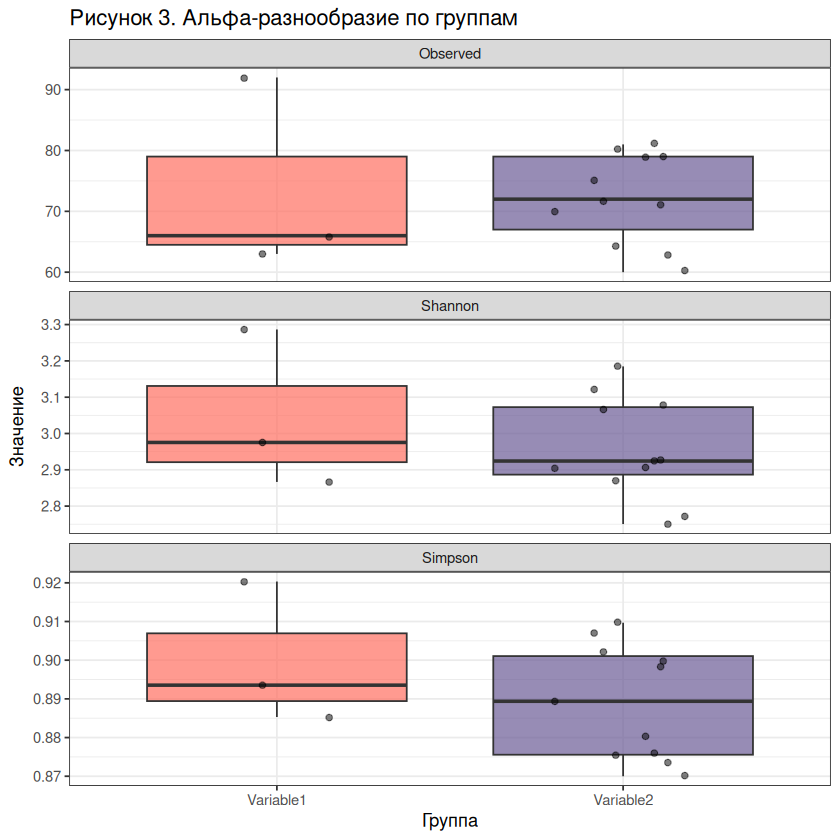

In [75]:
alpha_long <- reshape2::melt(alpha_df,
                              id.vars = c("Sample", "Param1"),
                              measure.vars = c("Observed", "Shannon", "Simpson"),
                              variable.name = "Index",
                              value.name = "Value")

alpha_plot <- ggplot(alpha_long, aes(x = Param1, y = Value, fill = Param1)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.5) +
  facet_wrap(~ Index, scales = "free_y", ncol = 1) +
  scale_fill_manual(values = palette) +
  labs(title = "Рисунок 3. Альфа-разнообразие по группам",
       x = "Группа", y = "Значение") +
  theme_bw() +
  theme(legend.position = "none")

print(alpha_plot)

ggsave("alpha_diversity.png", width = 6, height = 8)

In [80]:
test_obs <- wilcox.test(Observed ~ Param1, data = alpha_df)
test_shan <- wilcox.test(Shannon ~ Param1, data = alpha_df)
test_simp <- wilcox.test(Simpson ~ Param1, data = alpha_df)

cat("Результаты теста Уилкоксона для альфа-разнообразия (по Param1):\n")
cat("Observed: W =", test_obs$statistic, ", p-value =", round(test_obs$p.value, 4), "\n")
cat("Shannon:  W =", test_shan$statistic, ", p-value =", round(test_shan$p.value, 4), "\n")
cat("Simpson:  W =", test_simp$statistic, ", p-value =", round(test_simp$p.value, 4), "\n")

Результаты теста Уилкоксона для альфа-разнообразия (по Param1):
Observed: W = 15.5 , p-value = 0.9378 
Shannon:  W = 20 , p-value = 0.6593 
Simpson:  W = 22 , p-value = 0.456 


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,0.02424318,0.04315284,0.5411878,0.847
Residual,12,0.53755498,0.95684716,NA,NA
Total,13,0.56179816,1.00000000,NA,NA


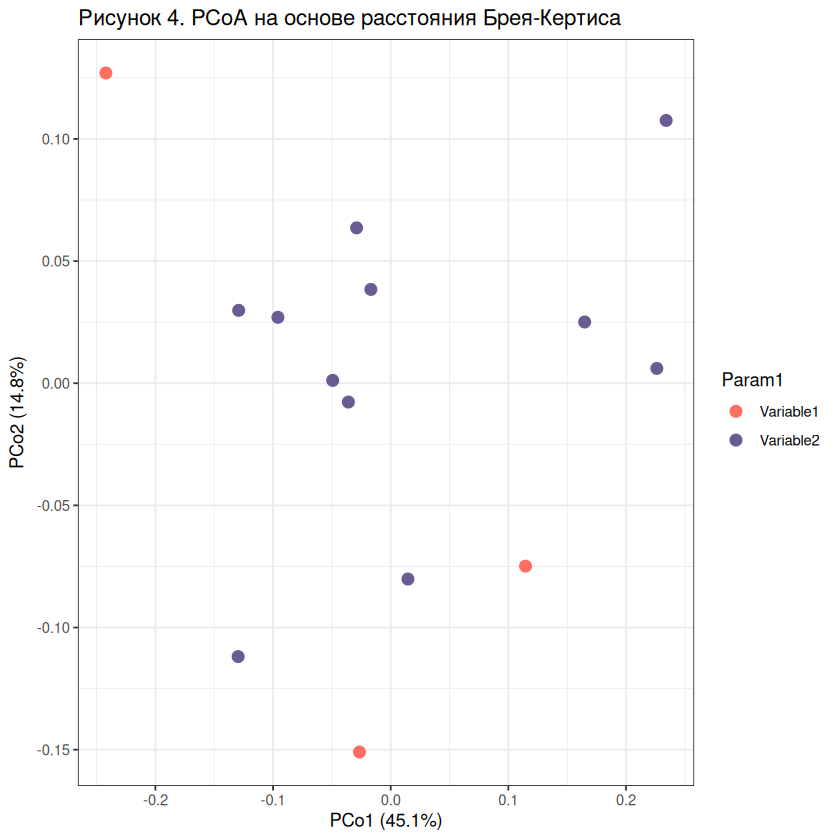

In [74]:
bray_dist <- phyloseq::distance(genus_phy, method = "bray")
pcoa <- ordinate(genus_phy, method = "PCoA", distance = bray_dist)
eigenvals <- pcoa$values$Eigenvalues
var_exp <- round(eigenvals / sum(eigenvals) * 100, 1)
pcoa_plot <- plot_ordination(genus_phy, pcoa, color = "Param1") +
  geom_point(size = 3) +
  scale_color_manual(values = palette) +
  labs(title = "Рисунок 4. PCoA на основе расстояния Брея-Кертиса",
       x = paste0("PCo1 (", var_exp[1], "%)"),
       y = paste0("PCo2 (", var_exp[2], "%)")) +
  theme_bw()
print(pcoa_plot)
ggsave("beta_diversity_pcoa.png", width = 7, height = 5)
library(vegan)
metadata_df <- data.frame(sample_data(genus_phy))
adonis2(bray_dist ~ Param1, data = metadata_df)